<a href="https://colab.research.google.com/github/j2tori-design/DA-study/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D_with_%ED%8C%8C%EC%9D%B4%EC%8D%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 데이터 분석에 대하여**

**데이터 다운로드**

In [ ]:
import gdown
gdown.download('https://bit.ly/3eecMKZ', '도서관 대출 목록.csv', quiet = False)

Downloading...
From: https://bit.ly/3eecMKZ
To: /content/도서관 대출 목록.csv
100%|██████████| 58.1M/58.1M [00:00<00:00, 195MB/s]


'도서관 대출 목록.csv'

## **CSV 파일 출력**

In [ ]:
with open('도서관 대출 목록.csv') as f:
          print(f.readline())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb9 in position 0: invalid start byte

위와 같은 오류는 파일 인코딩 형식이 다르기 떄문에 발생
- open : UTF-8이라고 가정
- 한글 텍스트 : EUC-KR 사용

open() 사용 시 mode 매개변수
- 기본값 : 텍스트 읽기 모드인 'r'
- 바이너리 읽기 모드인 'rb'로 바꾸면 인코딩 방식에 상관없이 파일을 열 수 있다

### **인코딩 형식 확인**

In [ ]:
import chardet
with open('도서관 대출 목록.csv', mode = 'rb') as f:
          d = f.readline()
print(chardet.detect(d))

{'encoding': 'EUC-KR', 'confidence': 0.99, 'language': 'Korean'}


### **인코딩 형식 지정**
- encoding 매개변수 사용

In [ ]:
with open('도서관 대출 목록.csv', encoding = 'EUC-KR') as f:
          print(f.readline())

번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,



## **데이터 프레임 다루기 : 판다스**
판다스는 csv파일을 읽어 데이터 프레임이라는 표 형식 데이터로 저장
- 시리즈 : 동일 데이터 타입을 담은 배열
- 데이터프레임 : 열마다 다른 데이터 타입을 사용할 수 있는 2차원 배열
  - ex) 저자 열은 문자열, 번호 열은 정수

### **CSV 파일을 데이터프레임으로 읽기**

In [ ]:
# read_csv 함수
import pandas as pd
pd.read_csv('도서관 대출 목록.csv', encoding = 'EUC-KR')

/tmp/ipykernel_2327/70685456.py:3: DtypeWarning: Columns (5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv('도서관 대출 목록.csv', encoding = 'EUC-KR')


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401677,401678,韓國現代詩大系,채만묵 編著,한국문화사,1996,9788977352971,9788977352988.0,NaN,3,811.608,1,0,1970-01-01,NaN
401678,401679,뉴 웨이브,제임스 모나코 지음,한나래,1996,9788985367448,9788985367424.0,NaN,2,688.04,1,0,1970-01-01,NaN
401679,401680,(최인훈 장편소설)화두,최인훈 지음,민음사,1994,9788937401596,9788937401589.0,NaN,2,813.6,1,0,1970-01-01,NaN
401680,401681,독일 문학과 세계 문학,吳漢鎭 編著,벽호,1995,9788947700368,9788947700405.0,NaN,3,809.05,2,0,1970-01-01,NaN


- 판다스는 데이터 타입을 자동으로 파악하고 CSV 파일을 나누어 읽음. 그 과정에서 파악한 데이터 타입이 달라지면 위와 같은 dtype error 발생
- 해결방법
  - low_memory 매개변수를 False로 지정하여 파일을 한번에 읽기
  - dtype 매개변수로 데이터 타입 지정해주기

In [ ]:
# 방법1
df = pd.read_csv('도서관 대출 목록.csv', encoding = 'EUC-KR', low_memory = False)

In [ ]:
df.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


In [ ]:
# 방법2
df = pd.read_csv('도서관 대출 목록.csv', encoding='euc-kr',
                 dtype={'ISBN': str, '세트 ISBN': str, '주제분류번호': str})
df.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


- 첫 행이 이름이 아니라면 header 매개변수를 None으로 지정 & names 매개변수로 열 이름 리스트 따로 전달

### **데이터프레임을 CSV 파일로 저장하기**

In [ ]:
# to_csv() 함수
df.to_csv('ns_202606.csv')

In [ ]:
with open('ns_202606.csv') as f:
  for i in range(3):
    print(f.readline(), end=' ')

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
 0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,,,,1,0,2021-03-19,
 1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,,,,1,0,2021-03-19,
 

- 데이터프레임에 있던 행 인덱스가 같이 저장되어서 출력됨

In [ ]:
ns_df = pd.read_csv('ns_202606.csv', low_memory = False)
ns_df.head()

,Unnamed: 0,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


- 인덱스가 중복되므로 index_col 매개변수를 사용해 하나 삭제

In [ ]:
ns_df = pd.read_csv('ns_202606.csv', index_col = 0, low_memory = False)
ns_df.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


- 애초에 저장할 때 인덱스를 빼고 저장할 수도 있다

In [ ]:
df.to_csv('ns_202606.csv', index = False)

# **2. 데이터 수집하기**

## **2-1. API 사용하기**
- application programming interface

**API 방식이란?**
- 데이터베이스에 직접 접근하기 힘들때 인증된 URL을 통해 필요한 데이터에 편리하게 접근하는 방식
- API : 두 프로그램이 서로 대화하기 위한 방법을 정의한 것
  - 서로 다른 프로그램끼리 대화할 때, 데이터 주고받는 규칙이 같아야함
  - 어플리케이션 간의 통신에는 웹기반 API가 사용됨
----------------
**웹 기반 API**
  - 웹 서버와 웹 브라우저는 HTTP를 통해 웹 페이지를 구성하는 HTML 데이터를 주고받을 수 있음
    - HTTP : 인터넷에서 웹 페이지를 전송하는 기본 통신 방법
    - HTML : 웹 브라우저가 화면에 표시할 수 있는 문서의 한 종류, 웹페이지의 표준 언어
  - 웹 기반 API에서는 HTML을 주고받는 것이 아닌, CSV, JSON, XML 등의 파일 사용
    - HTML : 전부 텍스트 파일 & 복잡한 구조
    - CSV : 각 행마다 항목의 개수가 맞아야하고 행과 열로만 구성
    -> 복잡한 데이터 구현 어려움
    - 따라서 JSON XML이 많이 사용됨


### **JSON 데이터 다루기**

- 웹 기반 API에서 사용하는 HTTP 프로토콜은 **텍스트 기반**이기 때문에 파이썬 객체를 문자열로 바꾸어 송수신한다

In [ ]:
# JSON 형식
d = {"name" : "혼자 공부하는 데이터 분석"}
print(d['name'])

혼자 공부하는 데이터 분석


In [ ]:
import json

In [ ]:
# dumps() : 파이썬 객체를 문자열로 변환하는 함수
d_str = json.dumps(d, ensure_ascii = False)
print(d_str)
print(type(d_str))

{"name": "혼자 공부하는 데이터 분석"}
<class 'str'>


In [ ]:
# loads() : 문자열을 파이썬 객체로 변환하는 함수
d2 = json.loads(d_str)
print(d2['name'])
print(type(d2))

혼자 공부하는 데이터 분석
<class 'dict'>


- 더 복잡한 구조의 데이터 주고받을 수 있을까?

In [ ]:
# JSON은 대괄호 내에 여러 항목 나열 가능
d3 = json.loads('{"name" : "혼자 공부하는 데이터 분석", "author" : ["박해선", "홍길동"], "year" : 2022}')
print(d3['name'])
print(d3['author'])
print(d3['year'])
print(d3['author'][0])

혼자 공부하는 데이터 분석
['박해선', '홍길동']
2022
박해선


In [ ]:
# JSON 배열로 더 복잡한 데이터 처리 가능
data = [
  {"name" : "혼자 공부하는 데이터 분석", "author" : "박해선", "year" : 2020},
  {"name" : "혼자 공부하는 머신러닝+딥러닝", "author" : "박해선", "year" : 2021}
]
d4_str = json.dumps(data, ensure_ascii = False)

In [ ]:
d4 = json.loads(d4_str)
print(d4[0]['name'])
print(d4[1]['year'])

혼자 공부하는 데이터 분석
2021


JSON 문자열을 바로 데이터프레임으로 변환하기
- 판다스가 변환 함수 read_json() 제공해줌

In [ ]:
from io import StringIO
import pandas as pd
pd.read_json(StringIO(d4_str))

,name,author,year
0,혼자 공부하는 데이터 분석,박해선,2020
1,혼자 공부하는 머신러닝+딥러닝,박해선,2021


JSON을 데이터프레임으로 변환하기
- JSON 문자열을 파이썬 객체로 변환후 DataFrame 클래스 사용

In [ ]:
pd.DataFrame(d4)

,name,author,year
0,혼자 공부하는 데이터 분석,박해선,2020
1,혼자 공부하는 머신러닝+딥러닝,박해선,2021


### **XML 데이터 다루기**

컴퓨터와 사람이 모두 읽고 쓰기 편한 문서 포맷을 위해 구현
- 루트 엘리먼트와 자식 엘리먼트로 구성

In [ ]:
# fromstring() : XML 문자열을 파이썬 객체로 변환하는 함수
import xml.etree.ElementTree as et
x_str = """
<book>
  <name>혼자 공부하는 데이터 분석</name>
  <author>박해선</author>
  <year>2022</year>
</book>
"""
book = et.fromstring(x_str)

In [ ]:
# fromstring에 의해 변환된 객체는 단순 파이썬 객체가 아니라
# ElementTree 모듈 아래에 정의된 Element 클래스의 객체
print(type(book))

<class 'xml.etree.ElementTree.Element'>


In [ ]:
# tag로 element 이름 확인
print(book.tag)

book


이 **XML 문서에서 원하는 값들 추출**하려면
- <book> element의 자식 엘리먼트 구하고
  - 이때, list()를 통해 객체를 리스트로 변환하여 구할 수 있다
- 각각의 자식 엘리먼트에 담긴 텍스트 읽기

In [ ]:
# 객체를 리스트로 변환하기
book_childs = list(book)
print(book_childs)

[<Element 'name' at 0x7f9684a704f0>, <Element 'author' at 0x7f9684a70540>, <Element 'year' at 0x7f9684a705e0>]


In [ ]:
# 각각을 변수에 할당
# text 속성으로 엘리먼트에 있는 텍스트 출력
name, author, year = book_childs
print(name.text)
print(author.text)
print(year.text)

혼자 공부하는 데이터 분석
박해선
2022


하지만, XML은 자식 엘리먼트 순서를 보장해주지 못함
- 위처럼 book_childs를 이용한 방식은 위험
- findtext() 함수 사용

In [ ]:
name = book.findtext('name')
author = book.findtext('author')
year = book.findtext('year')
print(name)
print(author)
print(year)

혼자 공부하는 데이터 분석
박해선
2022


- 더 복잡한 문서는 어떻게 처리할까?
  - JSON과 달리 배열 구조는 없음
  - 2개의 <book>를 감싸는 부모 엘리먼트 만들면 됨

In [ ]:
x2_str = """
<books>
  <book>
    <name>혼자 공부하는 데이터 분석</name>
    <author>박해선</author>
    <year>2022</year>
  </book>
  <book>
    <name>혼자 공부하는 머신러닝/딥러닝</name>
    <author>박해선</author>
    <year>2021</year>
  </book>
</books>
"""
books = et.fromstring(x2_str)
print(books.tag)

books


이처럼 동일한 이름을 가진 여러개의 자식 엘리먼트 찾을 때에는
- findall()과 for문을 함께 사용
  - 부모 엘리먼트인 books에 대해 findall() 사용

In [ ]:
for book in books.findall('book'):
  name = book.findtext('name')
  author = book.findtext('author')
  year = book.findtext('year')
  print(name)
  print(author)
  print(year)

혼자 공부하는 데이터 분석
박해선
2022
혼자 공부하는 머신러닝/딥러닝
박해선
2021


XML을 데이터프레임으로 변환하기

In [ ]:
pd.read_xml(x2_str)

/tmp/ipykernel_2327/212699965.py:1: FutureWarning: Passing literal xml to 'read_xml' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_xml(x2_str)


,name,author,year
0,혼자 공부하는 데이터 분석,박해선,2022
1,혼자 공부하는 머신러닝/딥러닝,박해선,2021


### **API로 20대가 좋아하는 도서 찾기**

**API를 호출하는 URL 작성하기**
- 공개 API를 사용하려면 호출 URL 필요
- HTTP GET 방식을 통해 조회한다
  - 호출 URL 뒤에 파라미터로 조회할 값을 연결하는 방식
    - ex) 호출주소 ? 파라미터1=값1 & 파라미터2=값2

http://data4library.kr/api/loanItemSrch?format=json&startDt=2022-01-01&endDt=2022-03-31&age=20&authKey=65f29f1438fa9253d4df43ba7cfad992fa54d31c94f19d4a3cd8187c904b7ad4

매번 브라우저에 주소를 입력해 JSON 데이터를 가져오는 것은 수동적
- 대신, 웹 브라우저 사용없이 공개 API에서 JSON 데이터를 자동으로 추출하는 프로그램 사용하자

**파이썬으로 API 호출하기**
- requests 패키지 사용(매우 중요!!)

In [ ]:
import requests

In [ ]:
url = "http://data4library.kr/api/loanItemSrch?format=json&startDt=2022-01-01&endDt=2022-03-31&age=20&authKey=65f29f1438fa9253d4df43ba7cfad992fa54d31c94f19d4a3cd8187c904b7ad4"

In [ ]:
# URL을 requests.get() 함수에 전달
# API 주소로 데이터를 받는다
r = requests.get(url)

In [ ]:
data = r.json()
print(data)

{'response': {'request': {'startDt': '2022-01-01', 'endDt': '2022-03-31', 'age': '20', 'pageNo': 1, 'pageSize': 200, 'format': 'json'}, 'resultNum': 200, 'numFound': 5000, 'docs': [{'doc': {'no': 1, 'ranking': '1', 'bookname': '시선으로부터, :정세랑 장편소설 ', 'authors': '지은이: 정세랑', 'publisher': '문학동네', 'publication_year': '2020', 'isbn13': '9788954672214', 'addition_symbol': '03810', 'vol': '', 'class_no': '813.7', 'class_nm': '문학 > 한국문학 > 소설', 'bookImageURL': 'https://image.aladin.co.kr/product/24131/37/cover/8954672213_1.jpg', 'bookDtlUrl': 'https://data4library.kr/bookV?seq=5674475', 'loan_count': '1772'}}, {'doc': {'no': 2, 'ranking': '2', 'bookname': '우리가 빛의 속도로 갈 수 없다면 :김초엽 소설 ', 'authors': '지은이: 김초엽', 'publisher': '허블', 'publication_year': '2019', 'isbn13': '9791190090018', 'addition_symbol': '03810', 'vol': '', 'class_no': '813.7', 'class_nm': '문학 > 한국문학 > 소설', 'bookImageURL': 'https://image.aladin.co.kr/product/19359/16/cover/s972635417_1.jpg', 'bookDtlUrl': 'https://data4library.kr/book

In [ ]:
data

{'response': {'request': {'startDt': '2022-01-01',
   'endDt': '2022-03-31',
   'age': '20',
   'pageNo': 1,
   'pageSize': 200,
   'format': 'json'},
  'resultNum': 200,
  'numFound': 5000,
  'docs': [{'doc': {'no': 1,
     'ranking': '1',
     'bookname': '시선으로부터, :정세랑 장편소설 ',
     'authors': '지은이: 정세랑',
     'publisher': '문학동네',
     'publication_year': '2020',
     'isbn13': '9788954672214',
     'addition_symbol': '03810',
     'vol': '',
     'class_no': '813.7',
     'class_nm': '문학 > 한국문학 > 소설',
     'bookImageURL': 'https://image.aladin.co.kr/product/24131/37/cover/8954672213_1.jpg',
     'bookDtlUrl': 'https://data4library.kr/bookV?seq=5674475',
     'loan_count': '1772'}},
   {'doc': {'no': 2,
     'ranking': '2',
     'bookname': '우리가 빛의 속도로 갈 수 없다면 :김초엽 소설 ',
     'authors': '지은이: 김초엽',
     'publisher': '허블',
     'publication_year': '2019',
     'isbn13': '9791190090018',
     'addition_symbol': '03810',
     'vol': '',
     'class_no': '813.7',
     'class_nm': '문학 > 한국

- 실제 도서 정보는 doc키에 매핑된 딕셔너리에 들어있음
- 이 JSON 데이터를 판다스 데이터프레임으로 변환하기 위해 딕셔너리 구조 바꾸자

In [ ]:
books = []
for d in data['response']['docs']:
  books.append(d['doc'])

In [ ]:
books

[{'no': 1,
  'ranking': '1',
  'bookname': '시선으로부터, :정세랑 장편소설 ',
  'authors': '지은이: 정세랑',
  'publisher': '문학동네',
  'publication_year': '2020',
  'isbn13': '9788954672214',
  'addition_symbol': '03810',
  'vol': '',
  'class_no': '813.7',
  'class_nm': '문학 > 한국문학 > 소설',
  'bookImageURL': 'https://image.aladin.co.kr/product/24131/37/cover/8954672213_1.jpg',
  'bookDtlUrl': 'https://data4library.kr/bookV?seq=5674475',
  'loan_count': '1772'},
 {'no': 2,
  'ranking': '2',
  'bookname': '우리가 빛의 속도로 갈 수 없다면 :김초엽 소설 ',
  'authors': '지은이: 김초엽',
  'publisher': '허블',
  'publication_year': '2019',
  'isbn13': '9791190090018',
  'addition_symbol': '03810',
  'vol': '',
  'class_no': '813.7',
  'class_nm': '문학 > 한국문학 > 소설',
  'bookImageURL': 'https://image.aladin.co.kr/product/19359/16/cover/s972635417_1.jpg',
  'bookDtlUrl': 'https://data4library.kr/bookV?seq=5430429',
  'loan_count': '1751'},
 {'no': 3,
  'ranking': '3',
  'bookname': '달러구트 꿈 백화점 :주문하신 꿈은 매진입니다 ',
  'authors': '지은이: 이미예',
  'publ

In [ ]:
import pandas as pd
books_df = pd.DataFrame(books)
books_df

,no,ranking,bookname,authors,publisher,publication_year,isbn13,addition_symbol,vol,class_no,class_nm,bookImageURL,bookDtlUrl,loan_count
0,1,1,"시선으로부터, :정세랑 장편소설",지은이: 정세랑,문학동네,2020,9788954672214,03810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/24131/37/co...,https://data4library.kr/bookV?seq=5674475,1772
1,2,2,우리가 빛의 속도로 갈 수 없다면 :김초엽 소설,지은이: 김초엽,허블,2019,9791190090018,03810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/19359/16/co...,https://data4library.kr/bookV?seq=5430429,1751
2,3,3,달러구트 꿈 백화점 :주문하신 꿈은 매진입니다,지은이: 이미예,팩토리나인,2020,9791165341909,03810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/24512/70/co...,https://data4library.kr/bookV?seq=5707051,1723
3,4,4,지구 끝의 온실 :김초엽 장편소설,지은이: 김초엽,Giant Books(자이언트북스),2021,9791191824001,03810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/27692/63/co...,https://data4library.kr/bookV?seq=6065686,1670
4,5,5,지구에서 한아뿐 :정세랑 장편소설,지은이: 정세랑,난다,2019,9791188862290,03810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/19804/82/co...,https://data4library.kr/bookV?seq=5446546,1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,192,키르케 :매들린 밀러 장편소설,지은이: 매들린 밀러 ;옮긴이: 이은선,이봄,2020,9791190582308,03840,,843.6,문학 > 영미문학 > 소설,https://image.aladin.co.kr/product/24108/65/co...,https://data4library.kr/bookV?seq=5674923,312
196,197,197,네 이웃의 식탁 :구병모 장편소설,지은이: 구병모,민음사,2018,9788937473197,04810,,813.7,문학 > 한국문학 > 소설,https://image.aladin.co.kr/product/14953/80/co...,https://data4library.kr/bookV?seq=3766378,311
197,198,197,NFT 레볼루션 =현실과 메타버스를 넘나드는 새로운 경제 생태계의 탄생 /NFT r...,"성소라,스콧 맥러플린 지음",길벗,2021,9791165216603,03320,,321.97,사회과학 > 경제학 > 경제각론,https://image.aladin.co.kr/product/27849/7/cov...,https://data4library.kr/bookV?seq=6086396,311
198,199,199,방구석 미술관,조원재 지음,백도씨,2020,9788968332845,03600,2,650.4,"예술 > 회화, 도화 > 회화, 도화",https://image.aladin.co.kr/product/25566/91/co...,https://data4library.kr/bookV?seq=5799196,310


마지막으로 books_df의 내용을 JSON으로 변환하여 저장한다

In [ ]:
# to_json() 함수 사용
books_df.to_json('20s_best_book.json')

## **2-2. 웹 스크래핑 사용하기**

원하는 값을 제공하는 API가 존재하지 않는다면?
- (복습) 웹 서버와 웹 브라우저는 HTTP를 통해 웹 페이지를 구성하는 HTML 데이터를 주고받을 수 있음
  - request 패키지 사용하면됨

# **3. 데이터 정제하기**

데이터 정제
- 데이터에서 손상되거나 부정확한 부분 수정
- 불필요한 데이터 삭제, 불완전한 값 교환

## **3-1. 불필요한 데이터 삭제하기**

In [1]:
import gdown
gdown.download('https://bit.ly/3RhoNho','ns_202104.csv', quiet = False)

Downloading...
From: https://bit.ly/3RhoNho
To: /content/ns_202104.csv
100%|██████████| 57.6M/57.6M [00:00<00:00, 165MB/s]


'ns_202104.csv'

In [2]:
import pandas as pd
ns_df = pd.read_csv('ns_202104.csv', low_memory = False)
ns_df.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19,NaN


### **1) 열 삭제하기**

위 표에서 Unnamed:13이라는 불필요한 열이 추가됨 -> 삭제
- **loc 메서드**에 슬라이싱 사용!
  - .loc(행 선택, 열 선택)

In [3]:
ns_book = ns_df.loc[:, '번호':'등록일자']   # loc 매서드에서 슬라이싱은 하나 전의 값까지 가는 파이썬과는 달리 해당 값까지 출력
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


중간에 있는 열을 제외하고 선택하려면??
- 불리언 배열 사용

In [4]:
print(ns_df.columns)

Index(['번호', '도서명', '저자', '출판사', '발행년도', 'ISBN', '세트 ISBN', '부가기호', '권',
       '주제분류번호', '도서권수', '대출건수', '등록일자', 'Unnamed: 13'],
      dtype='object')


**원소별 비교** : 판다스 배열 성격의 객체는 어떤 값과 비교할 때 자동으로 배열에 있는 모든 원소와 하나씩 비교한다
- 결과로 불리언 값인 True, False 가 차례대로 나열되어 반환
  - (+a) 이 결과는 넘파이 배열이다.

In [5]:
ns_df.columns != 'Unnamed: 13'

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False])

In [6]:
selected_columns = ns_df.columns != '부가기호'  # 삭제하고 싶은 중간 열 불리언 값을 False로
ns_book = ns_df.loc[:, selected_columns]
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,1,0,2021-03-19,NaN
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,1,0,2021-03-19,NaN
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,1,0,2021-03-19,NaN
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,1,0,2021-03-19,NaN
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,1,0,2021-03-19,NaN


#### **drop() 메서드**
- .drop(삭제하려는 열 이름, axis 매개변수)
  - axis : 0은 행을 삭제하고, 1은 열을 삭제한다
- 삭제하려는 열을 리스트 형식으로 여러개 정할수 있음

In [7]:
ns_book = ns_df.drop('Unnamed: 13', axis = 1)
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [8]:
ns_book = ns_df.drop(['부가기호', 'Unnamed: 13'], axis = 1)
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,1,0,2021-03-19


현재 선택한 데이터프레임을 바로 수정하려면?
- inplace 매개변수 사용
- 새로운 변수를 만들지 않고도 바로 삭제 가능

In [9]:
ns_book.drop('주제분류번호', axis=1, inplace =True)
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,권,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,1,0,2021-03-19


#### **dropna() 메서드**
- NaN이 하나 이상 포함된 행이나 열 삭제

In [10]:
ns_book = ns_df.dropna(axis=1)    # NaN이 포함된 열 삭제
ns_book.head()

,번호,ISBN,도서권수,대출건수,등록일자
0,1,9788937444319,1,0,2021-03-19
1,2,9791190123969,1,0,2021-03-19
2,3,9788968332982,1,0,2021-03-19
3,4,9788970759906,1,0,2021-03-19
4,5,9788934990833,1,0,2021-03-19


모든 값이 NaN인 열만 삭제하려면?
- how 매개변수를 'all'로 지정해준다

In [11]:
ns_book = ns_df.dropna(axis=1, how='all')
ns_book.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


### **2) 행 삭제하기**

drop() 메서드로도 행 삭제 가능
- axis 매개변수를 0으로 지정하면됨

In [12]:
ns_book2 = ns_book.drop([0,1], axis=0)   # axis의 기본값이 0이므로 생략 가능
# 0부터 1까지의 행을 삭제한다
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19
5,6,처음 읽는 음식의 세계사,"미야자키 마사카츠 지음, 한세희 옮김",탐나는책,2021,9791189550370,NaN,NaN,NaN,NaN,1,0,2021-03-19
6,7,아르센 벵거 자서전 My Life in Red and White,"아르센 벵거 지음, 이성모 옮김",한즈미디어(한스미디어),2021,9791160075793,NaN,NaN,NaN,NaN,1,0,2021-03-19


#### **[] 연산자와 슬라이싱**

In [13]:
ns_book2 = ns_book[2:5]    # 파이썬의 슬라이싱처럼 마지막 인덱스 포함 X
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


#### **[] 연산자와 불리언 배열**
- 비교연산자를 활용해 원하는 행은 True로, 제외할 행은 False로 표시한 불리언 배열 생성

In [14]:
selected_rows = ns_df['출판사'] == '한빛미디어'
ns_book2 = ns_book[selected_rows]   # 열에 , : 슬라이싱은 생략 가능
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
60,61,(맛있는 디자인)프리미어 프로 CC: 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원,심수진,윤성우,김덕영 지음",한빛미디어,2021,9791162244029,NaN,1,2021,005.567,1,1,2021-03-15
70,71,처음 배우는 애저 (Azure Portal로 배우는 애저 도입부터 활용까지),김도균,한빛미디어,2020,9791162243695,NaN,NaN,NaN,005.74,1,1,2021-03-15
88,89,맛있는 디자인 프리미어 프로 CC 2021 - 쉽게 배워 제대로 써먹는 유튜브 영상 편집,"정지원, 심수진, 윤성우, 김덕영 (지은이)",한빛미디어,2021,9791162244029,NaN,NaN,NaN,NaN,0,0,2021-03-15
156,157,"실전 보고서 작성 기술 with 파워포인트, 워드, 한글",홍장표 지음,한빛미디어,2020,9791162243763,NaN,NaN,NaN,NaN,1,0,2021-03-12
198,199,처음 배우는 리액트 네이티브,김범준 지음,한빛미디어,2021,9791162243879,NaN,NaN,NaN,NaN,1,0,2021-03-12


In [15]:
ns_book2 = ns_book[ns_book['대출건수'] > 1000]    # 조건에 해당하는 항만 출력
ns_book2.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
94781,94782,"사피엔스 :유인원에서 사이보그까지, 인간 역사의 대담하고 위대한 질문",유발 하라리 지음 ;조현욱 옮김,김영사,2016,9788934972464,NaN,NaN,NaN,909,30,1468,2016-04-22
346944,346945,해커스 토익:Listening,David Cho 지음,해커스어학연구소,2005,9788990700148,NaN,1,NaN,740.77,29,1065,2005-02-01


### **3) 중복된 행 찾기**

#### **duplicated 메서드**
- 중복된 행 중 처음 행을 제외한 나머지 행은 True로, 나머지 모든 행은 False로 표시한 *불리안 배열*  반환
  - True : 중복, False : 중복X
- sum 함수로 중복된 행의 개수 반환 가능

In [16]:
sum(ns_book.duplicated())

0

ns_book 데이터프레임의 모든 행은 고유한 '번호'가 있으므로 중복된 행이 나올 수 없다
- '도서명', '저자', 등 다른 열로 중복된 행이 있는지 찾아본다면?
- subset 매개변수로 기준 열을 나열

In [17]:
sum(ns_book.duplicated(subset=['도서명','저자','ISBN']))

22096

**keep 매개변수** : 중복된 행을 모두 True로 표시한 불리언 배열 반환
- 어떤 데이터가 중복되었는지 확인 가능

In [18]:
dup_rows = ns_book.duplicated(subset=['도서명','저자','ISBN'], keep=False)
ns_book3 = ns_book[dup_rows]
ns_book3.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
109,110,파친코,이민진 지음 ;이미정 옮김,문학사상,2018,9788970129815,9788970129808,0,1,843.6,1,0,2021-03-12
110,111,파친코,이민진 지음 ;이미정 옮김,문학사상,2018,9788970129822,9788970129808,0,2,843.6,1,0,2021-03-12
111,112,보건교사 안은영 :정세랑 장편소설,지은이: 정세랑,민음사,2021,9788937479953,NaN,0,NaN,813.7,1,0,2021-03-12
112,113,보건교사 안은영 :정세랑 장편소설,지은이: 정세랑,민음사,2021,9788937479953,NaN,0,NaN,813.7,1,1,2021-03-12
113,114,스토너,존 윌리엄스 지음 ;김승욱 옮김,RHK(알에이치코리아),2021,9788925538297,NaN,0,NaN,843.5,1,0,2021-03-12


### **4) 그룹별로 모으기**

#### **groupby() 메서드**
- **by 매개변수** : 행을 합칠 때 기준이 되는 열 지정
- 지정된 열에 NaN이 포함되어 있으면 해당 행 삭제
  - 이를 막기 위해 **dropna 매개변수**를 False로 지정
  - = '연산할 때 NaN이 있는 행도 포함하겠다'

In [19]:
# 사용할 열들만 묶기
count_df = ns_book[['도서명','저자','ISBN','권','대출건수']]

In [20]:
group_df = count_df.groupby(by=['도서명', '저자', 'ISBN', '권'], dropna=False)
loan_count = group_df.sum()

In [21]:
loan_count = count_df.groupby(by=['도서명','저자','ISBN','권'], dropna=False).sum()
loan_count.head()

,,,,대출건수
도서명,저자,ISBN,권,
(꼭 필요한 것부터 쉽게 배우는) 자신만만 블로그 차근차근 배우기,김상현 지음,9788955025637,NaN,38
(맨처음 배우는) 세상의 직업,엘레오노라 바르소티 글 ·그림 ;김태은 옮김,9788992924146,NaN,10
(영잘원 리스닝과 패턴 영어의 절묘한 만남으로 태어난 ) 리스닝 ABC : 입문편,JD Kim 지음,9788993466089,NaN,4
(즉석에서 바로바로 활용하는) 일상생활 베트남어 첫걸음,FL4U컨텐츠 지음,9788971728000,NaN,3
",에게",이기린(이진희),9791196137014,NaN,0


### **5) 원본 데이터 업데이트하기**

대출건수를 원본 데이터프레임에 업데이트하자
- but, 원본에는 중복된 데이터가 존재
---------------------------
대출건수 업데이트 하기 전에,
1. duplicated() 메서드로 중복된 행을 True로 표시한 불리언 배열 만들기
2. 1번에서 구한 불리언 배열을 반전(~ 연산자)시켜서 중복되지 않은 고유한 행을 True로 표시
3. 2번에서 구한 불리언 배열을 사용해 원본 배열에서 고유한 행만 선택
- 위의 과정을 통해 각 종류별 유일한 행을 선택하자

In [22]:
dup_rows = ns_book.duplicated(subset=['도서명', '저자', 'ISBN', '권'])
unique_rows = ~dup_rows
ns_book3 = ns_book[unique_rows].copy()

In [23]:
sum(ns_book3.duplicated(subset=['도서명', '저자', 'ISBN', '권']))

0

#### **set_index() 메서드**
- 지정한 열을 인덱스로 설정
- **inplace() 매개변수**를 사용해 새로운 데이터프레임을 반환하지 않고 데이터프레임 수정

In [24]:
ns_book3.set_index(['도서명','저자','ISBN','권'], inplace=True)
ns_book3.head()

,,,,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
도서명,저자,ISBN,권,,,,,,,,,
인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


#### **update() 메서드**
- 다른 데이터프레임을 사용해 원본 데이터프레임 값 업데이트

In [25]:
ns_book3.update(loan_count)
ns_book3.head()

/tmp/ipykernel_1415/3051281402.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  ns_book3.update(loan_count)


,,,,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
도서명,저자,ISBN,권,,,,,,,,,
인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


**reset_index() 메서드**
- 데이터프레임 인덱스 재설정
- 인덱스 열 해제

In [26]:
ns_book4 = ns_book3.reset_index()
ns_book4.head()

,도서명,저자,ISBN,권,번호,출판사,발행년도,세트 ISBN,부가기호,주제분류번호,도서권수,대출건수,등록일자
0,인공지능과 흙,김동훈 지음,9788937444319,NaN,1,민음사,2021,NaN,NaN,NaN,1,0,2021-03-19
1,가짜 행복 권하는 사회,김태형 지음,9791190123969,NaN,2,갈매나무,2021,NaN,NaN,NaN,1,0,2021-03-19
2,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,9788968332982,NaN,3,블랙피쉬,2021,NaN,NaN,NaN,1,0,2021-03-19
3,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",9788970759906,NaN,4,문학세계사,2021,NaN,NaN,NaN,1,0,2021-03-19
4,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,9788934990833,NaN,5,김영사,2021,NaN,NaN,NaN,1,0,2021-03-19


대출건수 잘 합쳐졌는지 확인해보자

In [27]:
sum(ns_book['대출건수']>100)

2311

In [28]:
sum(ns_book4['대출건수']>100)

2550

In [29]:
# 열 순서 맞추기
ns_book4 = ns_book4[ns_book.columns]
ns_book4.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


최종 수정된 데이터프레임 저장

In [30]:
ns_book4.to_csv('ns_book4.csv', index=False)

### **6) 일괄 처리함수**

In [31]:
def data_cleaning(filename):
  ns_df = pd.read_csv(filename, low_memory = False)

  ns_book = ns_df.dropna(axis=1, how='all')

  count_df = ns_book[['도서명','저자','ISBN','권','대출건수']]
  loan_count = count_df.groupby(by=['도서명','저자','ISBN','권'], dropna=False).sum()

  dup_rows = ns_book.duplicated(subset=['도서명', '저자', 'ISBN', '권'], keep=False)
  unique_rows = ~dup_rows
  ns_book3 = ns_book[unique_rows].copy()

  ns_book3.set_index(['도서명','저자','ISBN','권'], inplace=True)
  ns_book3.update(loan_count)
  ns_book4 = ns_book3.reset_index()

  ns_book4 = ns_book4[ns_book.columns]

  return ns_book4

#### **equal() 메서드**
- 다른 데이터프레임과 동일한지 비교


In [32]:
new_ns_book4 = data_cleaning('ns_202104.csv')
ns_book4.equals(new_ns_book4)

/tmp/ipykernel_1415/1793771553.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  ns_book3.update(loan_count)


False

## **3-2. 잘못된 데이터 수정하기**

누락된 값이나 잘못된 값을 다루는 방법
- 판다스는 누락된 값을 기본적으로 NaN으로 표현

In [33]:
import gdown
gdown.download('https://bit.ly/3GisL6J', 'ns_book4.csv', quiet=False)

Downloading...
From: https://bit.ly/3GisL6J
To: /content/ns_book4.csv
100%|██████████| 55.5M/55.5M [00:00<00:00, 108MB/s]


'ns_book4.csv'

In [34]:
import pandas as pd
ns_book4 = pd.read_csv('ns_book4.csv', low_memory=False)
ns_book4.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0.0,2021-03-19


**info() 메서드** : NaN이 몇개 있는지 확인 가능

In [35]:
ns_book4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384591 entries, 0 to 384590
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   번호       384591 non-null  int64  
 1   도서명      384188 non-null  object 
 2   저자       384393 non-null  object 
 3   출판사      379950 non-null  object 
 4   발행년도     384577 non-null  object 
 5   ISBN     384591 non-null  object 
 6   세트 ISBN  56576 non-null   object 
 7   부가기호     310386 non-null  object 
 8   권        63378 non-null   object 
 9   주제분류번호   364727 non-null  object 
 10  도서권수     384591 non-null  int64  
 11  대출건수     384591 non-null  float64
 12  등록일자     384591 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 38.1+ MB


### **1) 누락된 값 처리하기**

#### **isna() 메서드**
각 행이 비어있는지 나타내는 불리언 배열 반환

In [36]:
ns_book4.isna().sum()   # sum()으로 개수 확인

,0
번호,0
도서명,403
저자,198
출판사,4641
발행년도,14
ISBN,0
세트 ISBN,328015
부가기호,74205
권,321213
주제분류번호,19864


In [37]:
ns_book4.notna().sum()

,0
번호,384591
도서명,384188
저자,384393
출판사,379950
발행년도,384577
ISBN,384591
세트 ISBN,56576
부가기호,310386
권,63378
주제분류번호,364727


#### **None과 np.nan**
- 판다스는 정수 열에 None을 입력하면 누락된 값으로 인식

In [38]:
ns_book4.loc[0, '도서권수'] = None
ns_book4['도서권수'].isna().sum()

np.int64(1)

누락된 값이 하나 생김

In [39]:
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,NaN,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1.0,0.0,2021-03-19


판다스는 NaN을 특별한 실수 값으로 저장
-> int64였던 '도서권수' 열이 float64로 바뀜

**astype() 메서드** : 데이터 타입 지정
- 매개변수를 {열이름 : 데이터타입} 형식 딕셔너리로 전달

In [40]:
ns_book4.loc[0, '도서권수'] = 1
ns_book4 = ns_book4.astype({'도서권수':'int64', '대출건수':'int64'})
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


문자 열에 None을 입력하면?

In [41]:
ns_book4.loc[0,'부가기호'] = None
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,None,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


문자열 그대로 none으로 표시되므로 넘파이에 있는 np.nan 사용

In [42]:
import numpy as np
ns_book4.loc[0,'부가기호'] = np.nan
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


#### **누락된 값 바꾸기**

**loc,fillna() 메서드**

In [43]:
# loc 메서드로 누락된 값 -> 원하는 값으로 변경
set_isbn_na_rows = ns_book4['세트 ISBN'].isna()
ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = ''
ns_book4['세트 ISBN'].isna().sum()

np.int64(0)

In [44]:
# fillna 메서드로 더 쉽게 변경
ns_book4.fillna('없음').isna().sum()    # NaN -> '없음'

,0
번호,0
도서명,0
저자,0
출판사,0
발행년도,0
ISBN,0
세트 ISBN,0
부가기호,0
권,0
주제분류번호,0


In [45]:
# 부가기호 열의 NaN 바꾸면서 전체 데이터프레임 반환
ns_book4.fillna({'부가기호' : '없음'}).isna().sum()

,0
번호,0
도서명,403
저자,198
출판사,4641
발행년도,14
ISBN,0
세트 ISBN,0
부가기호,0
권,321213
주제분류번호,19864


**replace() 메서드**

변경 값이 하나일때

In [46]:
ns_book4.replace(np.nan, '없음').isna().sum()

,0
번호,0
도서명,0
저자,0
출판사,0
발행년도,0
ISBN,0
세트 ISBN,0
부가기호,0
권,0
주제분류번호,0


변경 값이 여러개일때

In [47]:
ns_book4.replace([np.nan, '2021'], ['없음', '21']).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,없음,없음,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,없음,없음,1,0,2021-03-19


In [48]:
ns_book4.replace({np.nan:'없음', '2021':'21'}).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,없음,없음,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,없음,없음,1,0,2021-03-19


열마다 다른 값으로 바꿀 때

In [49]:
ns_book4.replace({'부가기호':np.nan},'없음').head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,없음,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,없음,NaN,NaN,1,0,2021-03-19


In [50]:
ns_book4.replace({'부가기호': {np.nan : '없음'}, '발행년도': {'2021':'21'}}).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,NaN,NaN,1,0,2021-03-19


### **2) 잘못된 값 바꾸기**

In [52]:
ns_book4.astype({'발행년도':'int64'})

ValueError: invalid literal for int() with base 10: '1988.': Error while type casting for column '발행년도'

**contain() 메서드** : 문자열 패턴을 포함하고 있는지 검사
- na 매개변수를 True로 지정 -> 연도가 누락된 행을 True로 표시

In [56]:
ns_book4['발행년도'].str.contains('1988').sum()

407

**\D** : 정규표현식에서 숫자가 아닌 다른 모든 문자에 대응하는 표현

In [57]:
# 숫자 이외의 문자가 들어간 행에 대한 처리
invalid_number = ns_book4['발행년도'].str.contains(r'\D', na=True)
print(invalid_number.sum())
ns_book4[invalid_number].head()

1777


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
19138,19565,단국강토,홍태수 저,매일경제신문사,1988.,9788974420031,,NaN,NaN,511.1,1,1,2019-12-19
19227,19736,삼성의 역사,송부웅 撰,삼양,단기4334[2001],9788985464369,,0,NaN,911.02,1,1,2019-12-06
26097,26812,배고픈 애벌레,에릭 칼 글·그림 ;이희재 옮김,더큰컴퍼니,[2019],9788959514083,,NaN,NaN,843,1,0,2019-08-12
29817,30586,(The) Sopranos sessions,"Matt Zoller Seitz,$eAlan Sepinwall,$eLaura Lip...",Harry N Abrams Inc,2019.,9781419734946,,NaN,NaN,326.76,1,0,2019-06-13
29940,30709,다음엔 너야,에른스트 얀들 글;노르만 융에 그림;박상순 옮김,비룡소,2018.,9788949110646,9788949110004,7,NaN,853,1,9,2019-06-04


숫자 이외에 마침표, 대괄호, 한글 등이 들어간 값이 보임
- 정규표현식으로 연도 앞 뒤에 있는 문자들 제외시키자

In [58]:
ns_book5 = ns_book4.replace({'발행년도':r'.*(\d{4}).*'}, r'\1', regex=True)
ns_book5[invalid_number].head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
19138,19565,단국강토,홍태수 저,매일경제신문사,1988,9788974420031,,NaN,NaN,511.1,1,1,2019-12-19
19227,19736,삼성의 역사,송부웅 撰,삼양,2001,9788985464369,,0,NaN,911.02,1,1,2019-12-06
26097,26812,배고픈 애벌레,에릭 칼 글·그림 ;이희재 옮김,더큰컴퍼니,2019,9788959514083,,NaN,NaN,843,1,0,2019-08-12
29817,30586,(The) Sopranos sessions,"Matt Zoller Seitz,$eAlan Sepinwall,$eLaura Lip...",Harry N Abrams Inc,2019,9781419734946,,NaN,NaN,326.76,1,0,2019-06-13
29940,30709,다음엔 너야,에른스트 얀들 글;노르만 융에 그림;박상순 옮김,비룡소,2018,9788949110646,9788949110004,7,NaN,853,1,9,2019-06-04


숫자가 올바르게 바뀌었으니 다시 숫자 이외의 문자가 들어간 행의 개수와 데이터 확인해보자

In [59]:
unknown_year = ns_book5['발행년도'].str.contains(r'\D', na=True)
print(unknown_year.sum())
ns_book5[unknown_year].head()

67


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
30838,31616,본격 한중일 세계사 5,굽시니스트 지음,위즈덤하우스,NaN,9791190065092,,NaN,NaN,NaN,0,0,2019-05-28
39130,40141,정책금융의 현황과 발전과제,정책금융연구회,한국산업은행,NaN,9788992784108,,NaN,NaN,327.1,1,0,2019-01-22
39256,40268,서울지역 유적 발굴조사 총서 3,서울역사박물관,서울역사박물관,NaN,9791186324714,9791186324431,NaN,NaN,NaN,0,0,2019-01-22
76836,81202,흰머리 큰줄기,한호진 지음,秀文出版社,[발행년불명],9788973010769,,0,NaN,699.1,1,1,2016-11-10
150543,160436,(속) 경제학사,박장환 지음,NaN,[20--],9788994339207,,1,NaN,320.9,1,2,2012-11-19


1777개에서 67개로 엄청나게 줄어듬
- 나머지 변환되지 않은 값은 NaN 혹은 네자리가 아닌 숫자들
  - -1 값으로 바꾼 다음 astype() 메서드로 '발행년도' 열의 데이터 타입을 정수형으로 변환

In [60]:
ns_book5.loc[unknown_year, '발행년도'] = '-1'
ns_book5 = ns_book5.astype({'발행년도':'int64'})

#### 아주 큰 값이나 작은 값의 처리
 - **gt() 메서드** : 전달된 값보다 큰 값을 찾는 메서드
 - 그외에도 ge(), lt(), le(), eq(), ne() 등의 메서드 존재
    - 전부 대소비교 메서드

In [61]:
ns_book5['발행년도'].gt(4000).sum()   # 4000보다 큰 값을 가지는 행의 개수

np.int64(131)

In [62]:
danggun_yy_rows = ns_book5['발행년도'].gt(4000)   # 4000보다 큰 행 번호들을 변수에 저장
ns_book5.loc[danggun_yy_rows, '발행년도'] = ns_book5.loc[danggun_yy_rows, '발행년도'] - 2333

danggun_year = ns_book5['발행년도'].gt(4000)  # 서기로 변경했는데도 4000보다 큰 행들(이상치)
print(danggun_year.sum())
ns_book5[danggun_year].head(2)

13


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
222858,234268,Modern art,[computer file],GROLIER,7611,9780717233243,,NaN,NaN,609.205,1,1,2009-05-07
270269,282852,현대 영어학=Linguistic theory in modern english,이재영,열림기획,7634,9788986705072,,1,NaN,740.1,1,6,2007-04-14


연도가 이상하게 높은 값들 -> -1로 표시

In [63]:
ns_book5.loc[danggun_year, '발행년도'] = -1

연도가 작은 값도 확인해보자

In [64]:
old_books = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)  # 발행년도가 0보다 크고 1900보다 작은 값들
ns_book5[old_books]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
61149,64093,"고흐 씨, 시 읽어 줄까요 :내 마음을 알아주는 시와 그림의 만남",이운진 지음,사계절,176,9788958284277,,0,NaN,811.7,1,6,2017-10-27
70566,74347,정신 병리학의 문제들,지은이: 지그문트 프로이트 ;옮긴이: 황보석,열린책들,151,9788932905181,9788932905082,9,10,185.5,1,4,2017-04-26
79550,84164,(최근 7년간) 중요 민법판례 :[2009년 1월~2016년 6월 중요 판례],이광섭 편저,법학사,163,9788962898651,,9,NaN,365,1,14,2016-09-27
147950,157759,(한·중·일) 밥상 문화 :대표음식으로 본 3국 문화비교,김경은 지음,이가서,132,9788958643012,,0,NaN,381.75,1,30,2013-02-19
194576,205407,책으로 뒤덮인 집의 비밀,N.E. 보드 지음 ;피터 퍼거슨 그림 ;김지현 옮김,개암나무,1015,9788992844413,,7,NaN,843,1,15,2010-08-18
287252,300283,(밝혀질)우리歷史,吳在城 著,黎民族史硏究會,1607,9788986892130,,0,NaN,911,1,5,2006-07-06


연도가 이상하게 작은 값들도 -1로 설정

In [65]:
ns_book5.loc[old_books, '발행년도'] = -1

최종적으로 발행년도가 잘못된 행의 개수 출력

In [66]:
ns_book5['발행년도'].eq(-1).sum()

np.int64(86)

### **3) 누락된 정보 채우기**

데이터 분석에 중요하다고 판단한 열들에는 누락된 값이 있으면 안됨

In [67]:
na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())
ns_book5[na_rows].head(2)

5268


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
78,79,아산 정주영 레거시,김화진,NaN,2021,9788952129529,,NaN,NaN,325,1,1,2021-03-15
265,278,골목의 시간을 그리다,정명섭.김효찬 지음,NaN,2021,9791191266054,,NaN,NaN,NaN,1,0,2021-03-12


BeautifulSoup으로 누락되거나 값을 알 수 없는 행을 채우자

In [68]:
import requests
from bs4 import BeautifulSoup

In [69]:
def get_book_title(isbn):
    # Yes24 도서 검색 페이지 URL
    url = 'http://www.yes24.com/Product/Search?domain=BOOK&query={}'
    # URL에 ISBN을 넣어 HTML 가져옵니다.
    r = requests.get(url.format(isbn))
    soup = BeautifulSoup(r.text, 'html.parser')   # HTML 파싱
    # 클래스 이름이 'gd_name'인 a 태그의 텍스트를 가져옵니다.
    title = soup.find('a', attrs={'class':'gd_name'}) \
            .get_text()
    return title

In [70]:
get_book_title(9791191266054)

'골목의 시간을 그리다'

In [71]:
import re

def get_book_info(row):
    title = row['도서명']
    author = row['저자']
    pub = row['출판사']
    year = row['발행년도']
    # Yes24 도서 검색 페이지 URL
    url = 'http://www.yes24.com/Product/Search?domain=BOOK&query={}'
    # URL에 ISBN을 넣어 HTML 가져옵니다.
    r = requests.get(url.format(row['ISBN']))
    soup = BeautifulSoup(r.text, 'html.parser')   # HTML 파싱
    try:
        if pd.isna(title):
            # 클래스 이름이 'gd_name'인 a 태그의 텍스트를 가져옵니다.
            title = soup.find('a', attrs={'class':'gd_name'}) \
                    .get_text()
    except AttributeError:
        pass

    try:
        if pd.isna(author):
            # 클래스 이름이 'info_auth'인 span 태그 아래 a 태그의 텍스트를 가져옵니다.
            authors = soup.find('span', attrs={'class':'info_auth'}) \
                          .find_all('a')
            author_list = [auth.get_text() for auth in authors]
            author = ','.join(author_list)
    except AttributeError:
        pass

    try:
        if pd.isna(pub):
            # 클래스 이름이 'info_auth'인 span 태그 아래 a 태그의 텍스트를 가져옵니다.
            pub = soup.find('span', attrs={'class':'info_pub'}) \
                      .find('a') \
                      .get_text()
    except AttributeError:
        pass

    try:
        if year == -1:
            # 클래스 이름이 'info_date'인 span 태그 아래 텍스트를 가져옵니다.
            year_str = soup.find('span', attrs={'class':'info_date'}) \
                           .get_text()
            # 정규식으로 찾은 값 중에 첫 번째 것만 사용합니다.
            year = re.findall(r'\d{4}', year_str)[0]
    except AttributeError:
        pass

    return title, author, pub, year

In [72]:
updated_sample = ns_book5[na_rows].head(2).apply(get_book_info,
    axis=1, result_type ='expand')
updated_sample

,0,1,2,3
78,아산 정주영 레거시,김화진,서울대학교출판문화원,2021
265,골목의 시간을 그리다,정명섭.김효찬 지음,초록비책공방,2021


In [73]:
gdown.download('http://bit.ly/3UJZiHw', 'ns_book5_update.csv', quiet=False)

ns_book5_update = pd.read_csv('ns_book5_update.csv', index_col=0)
ns_book5_update.head()

Downloading...
From: http://bit.ly/3UJZiHw
To: /content/ns_book5_update.csv
100%|██████████| 406k/406k [00:00<00:00, 75.0MB/s]


,도서명,저자,출판사,발행년도
78,아산 정주영 레거시,김화진,서울대학교출판문화원,2021
265,골목의 시간을 그리다,정명섭.김효찬 지음,초록비책공방,2021
354,한국인의 맛,정명섭 지음,추수밭,2021
539,"한성부, 달 밝은 밤에",김이삭 지음,고즈넉이엔티,2021
607,100일 완성 마그마 러시아어 중고급 단어장,러포자 구제 연구소 외 지음,문예림,2021


In [74]:
ns_book5.update(ns_book5_update)

na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() \
          | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())

4615


'도서명', '저자', '출판사' 열에서 누락된 값이 있는 행을 삭제하고 '발행년도'가 -1이 아닌 행만 선택하여 ns_book6 데이터프레임 만들자
- ns_book6 : 정제된 데이터프레임

In [75]:
ns_book6 = ns_book5.dropna(subset=['도서명','저자','출판사'])
ns_book6 = ns_book6[ns_book6['발행년도'] != -1]
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,,NaN,NaN,NaN,1,0,2021-03-19


In [76]:
ns_book6.to_csv('ns_book6.csv', index=False)

### **4) 데이터를 이해하고 올바르게 정제하기**

In [77]:
def data_fixing(ns_book4):
    """
    잘못된 값을 수정하거나 NaN 값을 채우는 함수

    :param ns_book4: data_cleaning() 함수에서 전처리된 데이터프레임
    """
    # 도서권수와 대출건수를 int64로 바꿉니다.
    ns_book4 = ns_book4.astype({'도서권수':'int64', '대출건수': 'int64'})
    # NaN인 세트 ISBN을 빈문자열로 바꿉니다.
    set_isbn_na_rows = ns_book4['세트 ISBN'].isna()
    ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = ''

    # 발행년도 열에서 연도 네 자리를 추출하여 대체합니다. 나머지 발행년도는 -1로 바꿉니다.
    ns_book5 = ns_book4.replace({'발행년도':r'.*(\d{4}).*'}, r'\1', regex=True)
    unkown_year = ns_book5['발행년도'].str.contains(r'\D', na=True)
    ns_book5.loc[unkown_year, '발행년도'] = '-1'

    # 발행년도를 int64로 바꿉니다.
    ns_book5 = ns_book5.astype({'발행년도': 'int64'})
    # 4000년 이상인 경우 2333년을 뺍니다.
    dangun_yy_rows = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_yy_rows, '발행년도'] = ns_book5.loc[dangun_yy_rows, '발행년도'] - 2333
    # 여전히 4000년 이상인 경우 -1로 바꿉니다.
    dangun_year = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_year, '발행년도'] = -1
    # 0~1900년 사이의 발행년도는 -1로 바꿉니다.
    old_books = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)
    ns_book5.loc[old_books, '발행년도'] = -1

    # 도서명, 저자, 출판사가 NaN이거나 발행년도가 -1인 행을 찾습니다.
    na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() \
              | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
    # 교보문고 도서 상세 페이지에서 누락된 정보를 채웁니다.
    updated_sample = ns_book5[na_rows].apply(get_book_info,
        axis=1, result_type ='expand')
    updated_sample.columns = ['도서명','저자','출판사','발행년도']
    ns_book5.update(updated_sample)

    # 도서명, 저자, 출판사가 NaN이거나 발행년도가 -1인 행을 삭제합니다.
    ns_book6 = ns_book5.dropna(subset=['도서명','저자','출판사'])
    ns_book6 = ns_book6[ns_book6['발행년도'] != -1]

    return ns_book6

# **4. 데이터 요약하기**

## **4-1. 통계로 요약하기**

### **기술통계 구하기**

In [78]:
import gdown
gdown.download('https://bit.ly/3736JW1', 'ns_book6.csv', quiet=False)

Downloading...
From: https://bit.ly/3736JW1
To: /content/ns_book6.csv
100%|██████████| 55.0M/55.0M [00:00<00:00, 97.0MB/s]


'ns_book6.csv'

In [79]:
import pandas as pd

ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021.0,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021.0,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021.0,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021.0,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021.0,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


**describe() 메서드** : 기본적인 기술통계를 자동 추출

In [80]:
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


도서권수 최솟값이 0 ??? 이상한 값인가

In [81]:
sum(ns_book6['도서권수']==0)

3206

3천개 정도면 전체 데이터에 비해 무시할 만한 수준이라 제외한다

In [82]:
ns_book7 = ns_book6[ns_book6['도서권수']>0]

In [83]:
# describe 메서드에서 원하는 위치의 값 보여주도록
ns_book7.describe(percentiles=[0.3, 0.6, 0.9])

,번호,발행년도,도서권수,대출건수
count,376770.000000,376770.000000,376770.000000,376770.000000
mean,202977.476649,2008.460076,1.145540,11.593439
std,115298.245784,8.773148,0.473853,19.279409
min,1.000000,1947.000000,1.000000,0.000000
30%,124649.700000,2004.000000,1.000000,2.000000
50%,204550.500000,2009.000000,1.000000,6.000000
60%,243537.400000,2011.000000,1.000000,8.000000
90%,361341.100000,2018.000000,2.000000,28.000000
max,401681.000000,2650.000000,40.000000,1765.000000


열의 데이터타입이 수치가 아닌 열의 기술통계를 보고싶다면??
- include 매개변수 사용


In [84]:
ns_book7.describe(include='object')

,도서명,저자,출판사,ISBN,세트 ISBN,부가기호,권,주제분류번호,등록일자
count,376770,376770,376770,376770,55866,308252,61793,359792,376770
unique,336408,248850,21875,350810,14875,17,834,12467,4562
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788937430299,9788937460005,0,1,813.6,1970-01-01
freq,250,303,4410,206,702,158235,13282,14816,28185


### **기술통계 메서드들**
- 평균값 : mean()
- 중앙값 : median()
    - **drop_duplicate 메서드**를 사용해 중복을 제거한 후 중앙값을 구할 수 있음
- 최대, 최소 : max(), min()
- 분위수 계산 : quantile()
- 분산 : var(), 표준편차 : std()
- 최빈값 : mode()

### **데이터프레임에서 기술통계 구하기**

수치형 열만 연산 가능 -> 해당 열에만 적용하도록 **numeric_only 매개변수**를 True로 설정

In [85]:
ns_book7.mean(numeric_only = True)

,0
번호,202977.476649
발행년도,2008.460076
도서권수,1.145540
대출건수,11.593439


In [86]:
ns_book7.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012.0,9788937430299,9788937460005,0,1,813.6,1,0,1970-01-01


In [87]:
ns_book7.to_csv('ns_book7.csv', index=False)

## **4-2. 분포 요약하기**

In [88]:
import gdown
gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 181MB/s]


'ns_book7.csv'

In [89]:
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


### **산점도**

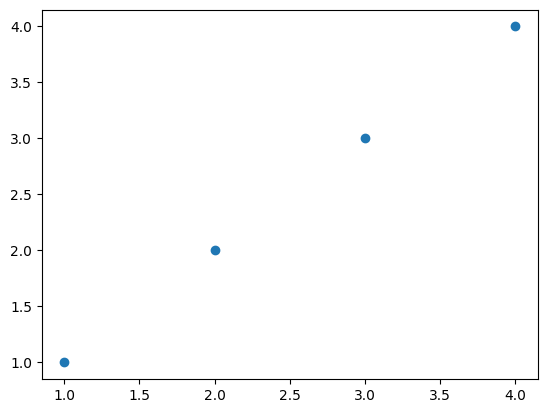

In [90]:
import matplotlib.pyplot as plt

plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()

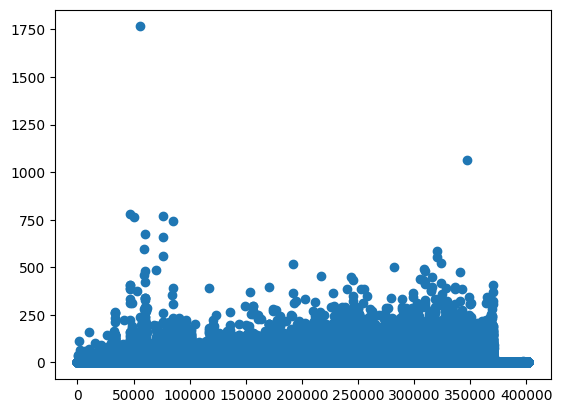

In [91]:
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
plt.show()

번호는 특별한 의미를 가지지 않으므로 도서권수로 다시 시도
- alpha 매개변수 : 투명도를 조절하여 중첩된 부분을 짙게 나타냄

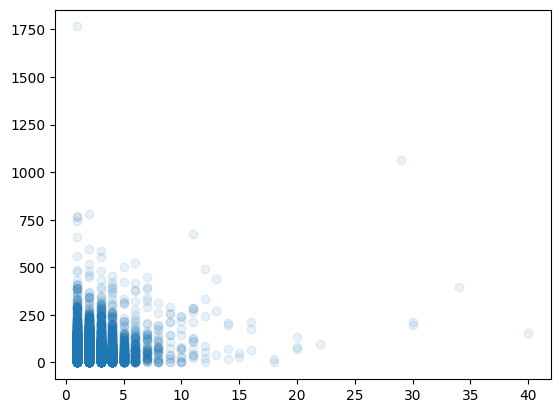

In [92]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

**양의 상관관계**를 가지는 그래프 그려보기

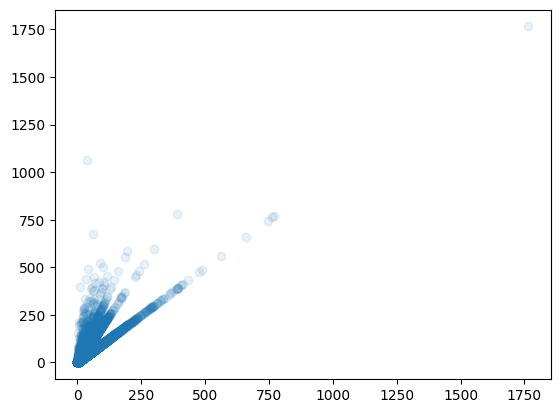

In [93]:
average_borrows = ns_book7['대출건수']/ns_book7['도서권수']
plt.scatter(average_borrows, ns_book7['대출건수'], alpha=0.1)
plt.show()

### **히스토그램**
- 하나의 특성에 대한 분포를 확인하기 좋다

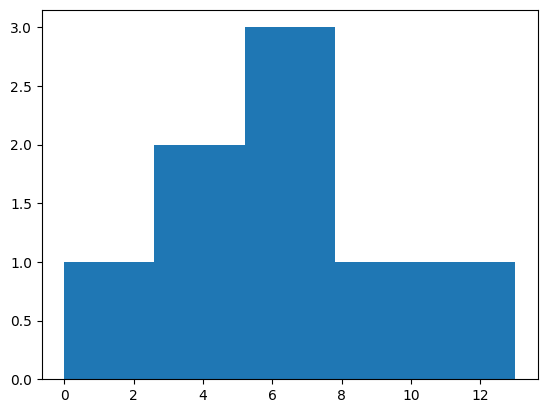

In [94]:
plt.hist([0,3,5,6,7,7,9,13], bins=5)
# 맷플롯립이 임의로 구간 설정
# bin 매개변수 : 몇개의 구간으로 나눌것인지
plt.show()

구간의 수치를 정확하게 알려면?

In [95]:
import numpy as np
np.histogram_bin_edges([0,3,5,6,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

**정규분포**
- 평균을 중심으로 좌우 대칭인 분포

In [96]:
np.random.seed(42)  # 유사난수 생성 옵션
random_samples = np.random.randn(1000)  # 1000개의 랜덤 데이터 생성

In [97]:
print(np.mean(random_samples))
print(np.std(random_samples))

0.01933205582232549
0.9787262077473543


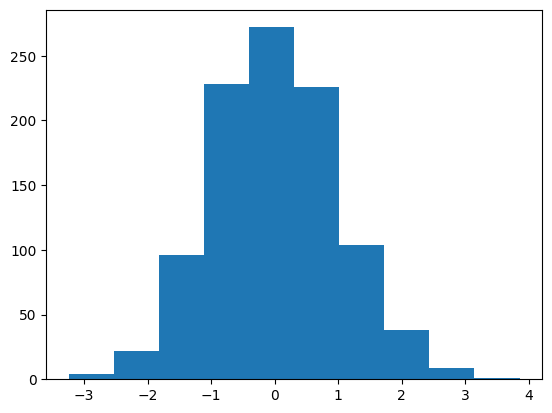

In [98]:
plt.hist(random_samples)
plt.show()

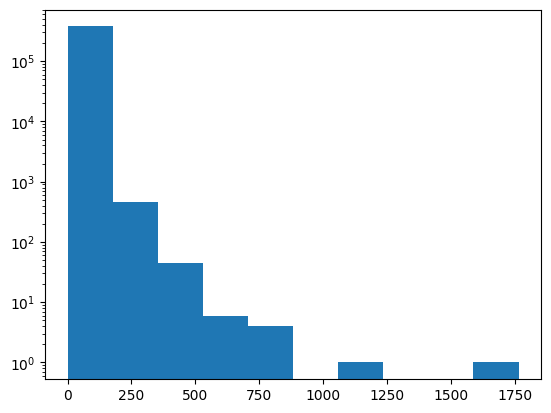

In [99]:
plt.hist(ns_book7['대출건수'])
plt.yscale('log')
# log scale : 작은 값을 상대적으로 부각되게 하려고 사용
plt.show()

bin 매개변수를 통해 데이터 분포를 더 세밀하게 관찰할 수도 있다

### **상자 수염 그래프**
- 여러개의 특성을 시각적으로 비교하기 좋다

- 박스는 25% ~ 75% 에 위치하는 값들
  - IQR : 박스의 길이
- 빨간선 : 중간값을 나타냄

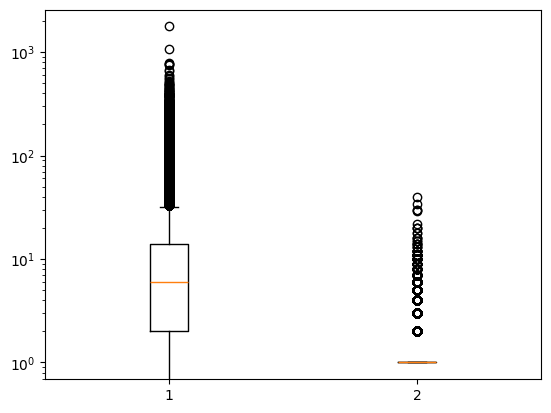

In [100]:
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')
plt.show()

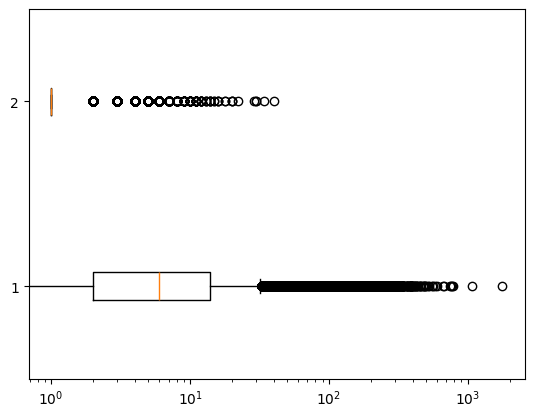

In [101]:
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log')
plt.show()

**whis 매개변수**로 수염 길이 조정 가능

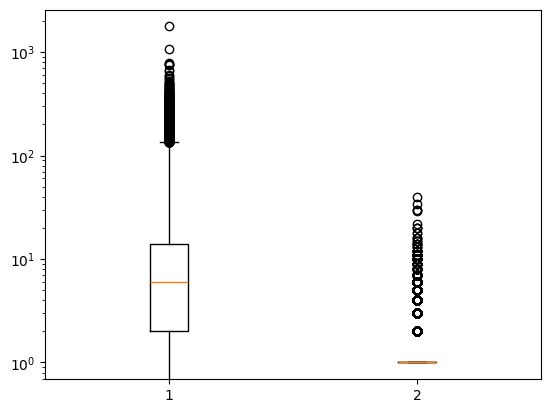

In [102]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)   # IQR의 10배로 수염길이 조정
plt.yscale('log')
plt.show()

# **5. 데이터 시각화**

## **5-1. 맷플롯립 기본 요소**

In [140]:
import gdown
gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 207MB/s]


'ns_book7.csv'

In [141]:
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


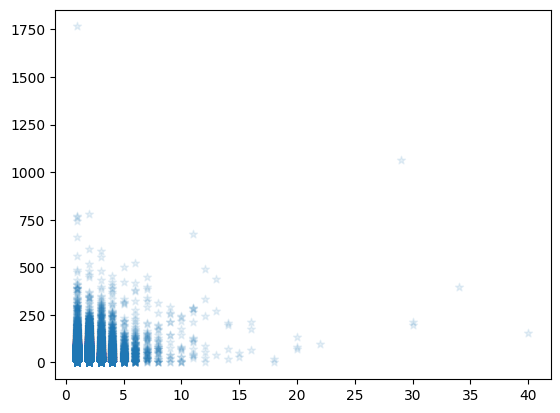

In [142]:
import matplotlib.pyplot as plt
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

### **1) Figure 객체**
- 모든 그래프 구성 요소를 담고 있는 최상위 객체


**figsize 매개변수** : 그래프 크기 조정 가능

In [143]:
print(plt.rcParams['figure.figsize'])   # 맷플롯립 기본 그래프 크기 확인

[6.4, 4.8]


show 함수가 실행되면 피겨 객체는 자동 소멸

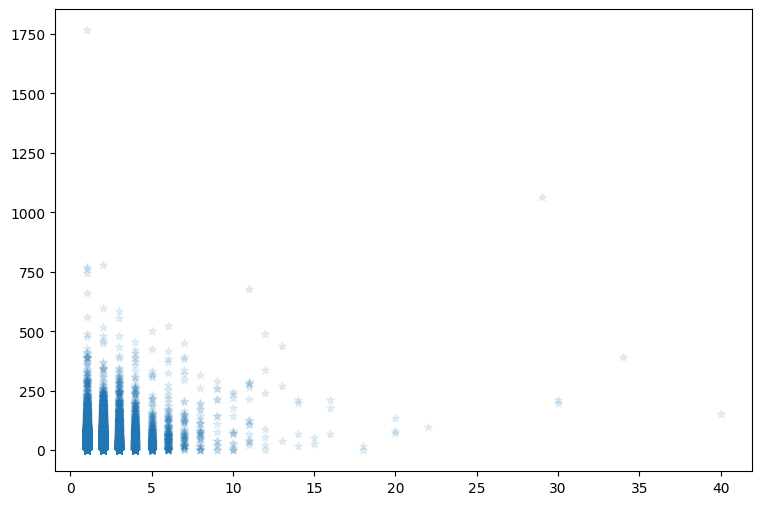

In [144]:
plt.figure(figsize=(9,6))   # 너비 9인치, 높이 6인치
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

**그래프 실제 크기 확인하기**
- DPI : 1인치를 몇개의 점으로 표현하는지 나타내는 값

In [145]:
print(plt.rcParams['figure.dpi'])

100.0


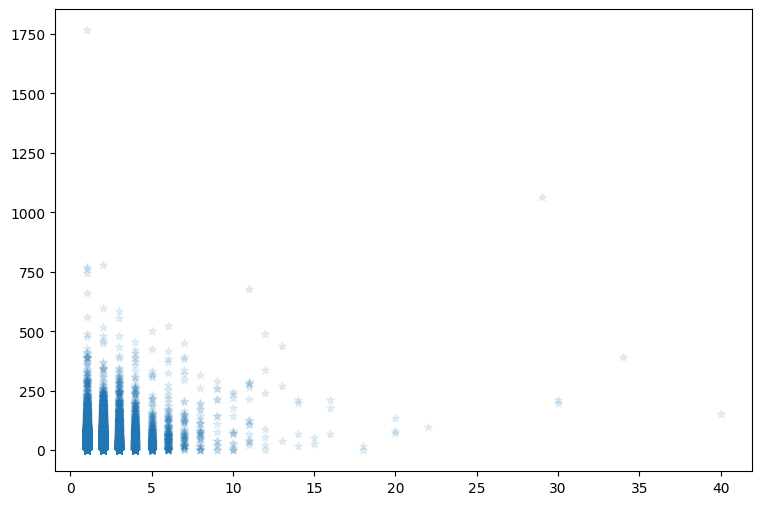

In [146]:
plt.figure(figsize=(900/100, 600/100))   # piece를 나누어서 구함
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

타이트 레이아웃을 사용하지 않으려면?
- bbox_inches 옵션을 None으로 지정

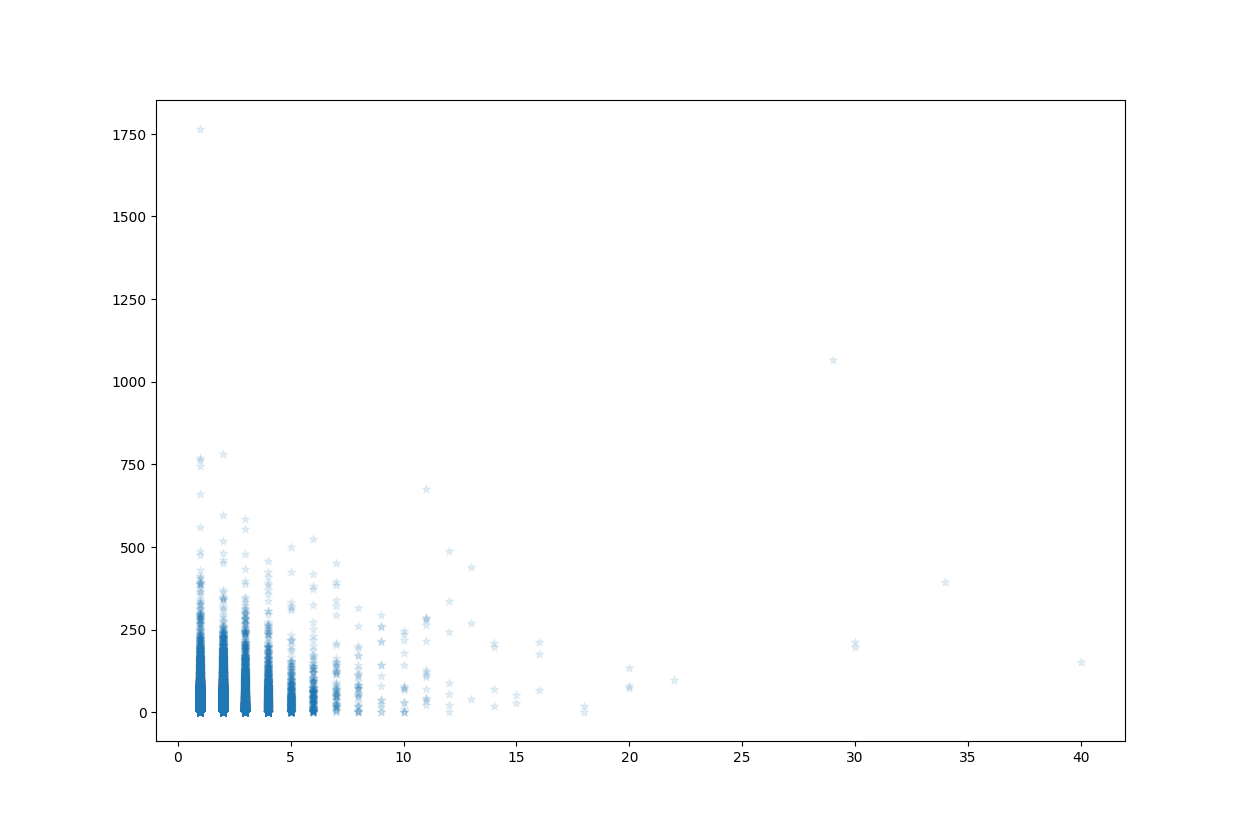

In [147]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
plt.figure(figsize=(900/72, 600/72))
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

In [148]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}

**dpi 매개변수**
- 그래프 내의 모든 구성 요소의 크기를 바꿀 수 있는 변수

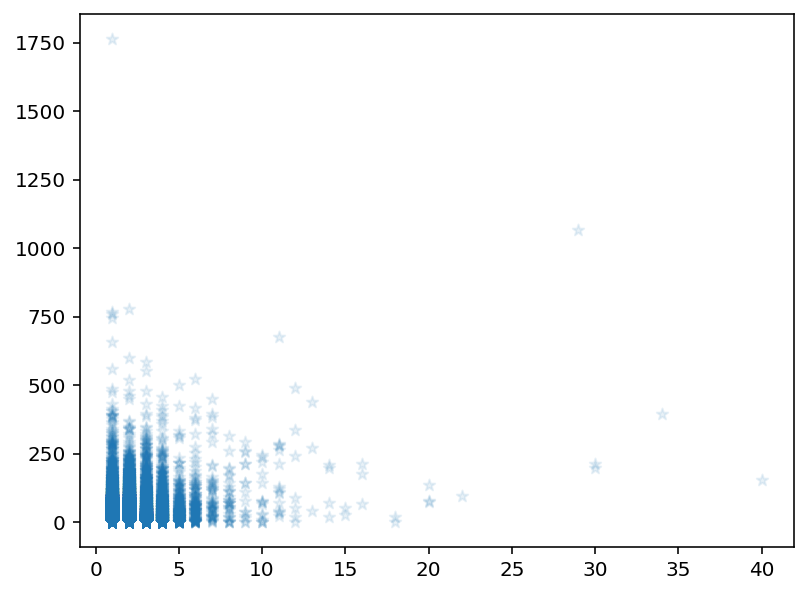

In [149]:
plt.figure(dpi=144)   # dpi를 2배 늘림
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

### **2) rcParams 객체**
- 맷플롯립 그래프의 기본값을 관리하는 객체

**DPI 기본값 바꾸기**
- 그래프의 해상도를 높이기 위해 dpi 기본값 변경

In [150]:
plt.rcParams['figure.dpi'] = 100

**산점도 마커 모양 바꾸기**

In [151]:
plt.rcParams['scatter.marker']

'*'

기본마커는 o이고 변경할수도 있다

In [152]:
plt.rcParams['scatter.marker'] = '*'

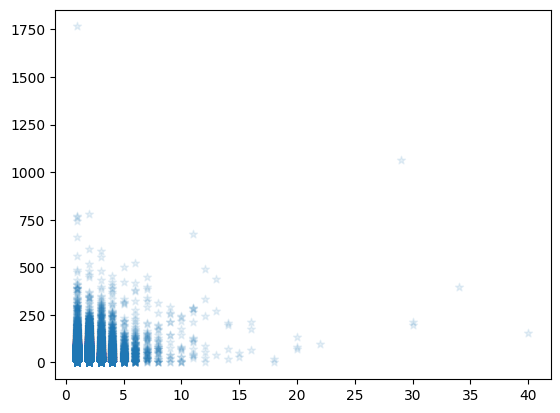

In [153]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

**marker 매개변수** : 마커의 모양 지정
- 객체의 scatter.marker 속성에 지정된 기본값을 무시하고 marker 매개변수에 지정된 값 이용

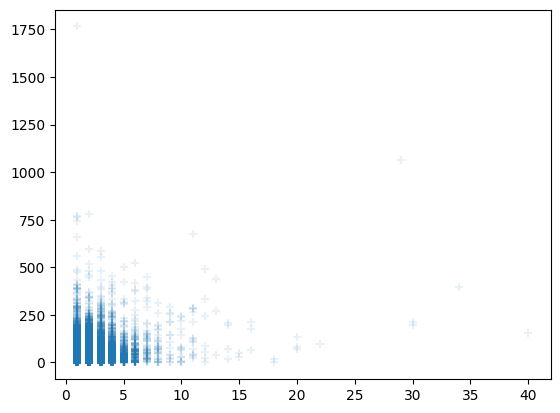

In [154]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1, marker='+')
plt.show()

### **3) 여러개의 서브플롯 출력하기**
- 하나의 피겨 객체 안에는 여러 개의 서브플롯을 담을 수 있다
  - 서브플롯 : 맷플롯립의 Axes(축) 클래스의 객체

**subplots() 함수**

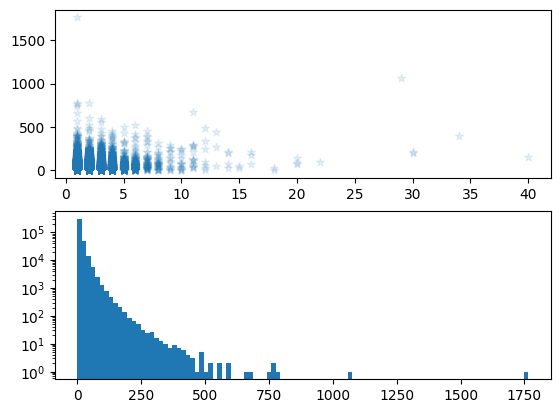

In [155]:
fig, axs = plt.subplots(2)    # 두개의 서브플롯 그리기

axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)    # 첫번째 그래프
axs[1].hist(ns_book7['대출건수'], bins=100)   # 두번째 그래프
axs[1].set_yscale('log')

fig.show()

각 그래프의 높이가 많이 줄어버림 -> 어떻게 해결?

**figsize 매개변수** : 피겨 크기를 지정할 수 있는 매개변수

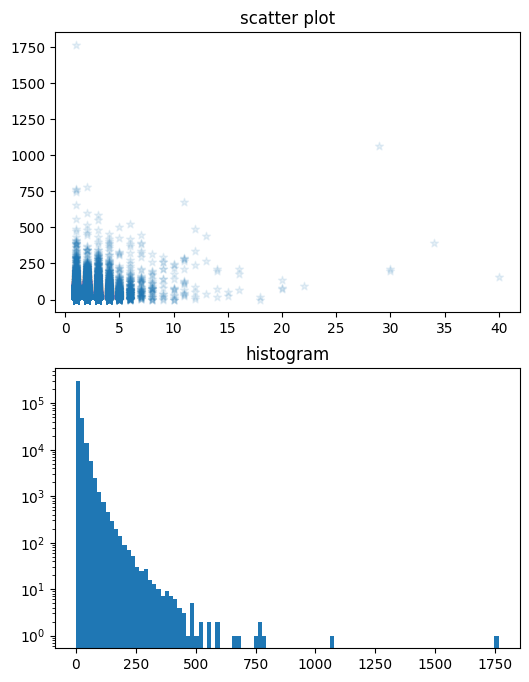

In [156]:
fig, axs = plt.subplots(2, figsize=(6, 8))

axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
axs[0].set_title('scatter plot')

axs[1].hist(ns_book7['대출건수'], bins=100)
axs[1].set_title('histogram')
axs[1].set_yscale('log')

fig.show()

**서브플롯을 가로로 나란히 출력하기**
- subplots() 함수에 행과 열을 지정하여 원하는 서브플롯 개수의 피겨 생성
  - 매개변수 : 행의 개수, 열의 개수
- set_xlabel, set_ylabel로 축 이름 지정

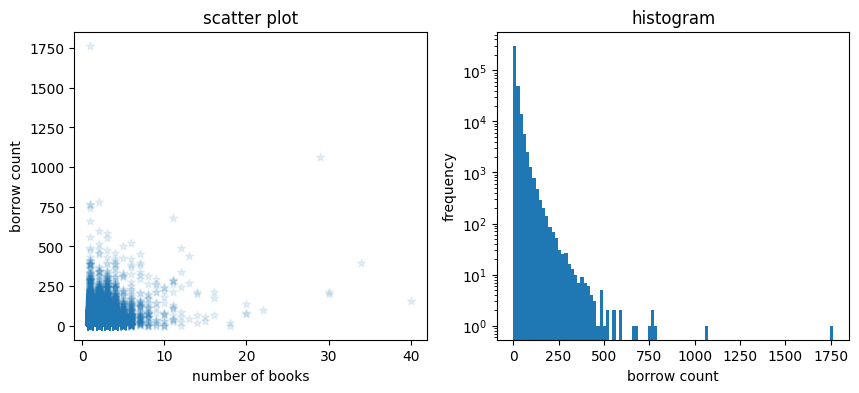

In [157]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
axs[0].set_title('scatter plot')
axs[0].set_xlabel('number of books')
axs[0].set_ylabel('borrow count')

axs[1].hist(ns_book7['대출건수'], bins=100)
axs[1].set_title('histogram')
axs[1].set_yscale('log')
axs[1].set_xlabel('borrow count')
axs[1].set_ylabel('frequency')

fig.show()

## **5-2. 선그래프와 막대그래프 그리기**

데이터의 변화를 살펴보는데 용이함

### **1) 연도별 발행 도서 개수 구하기**
- 선그래프를 그리기 용이하게 데이터 정제

In [170]:
import gdown
gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 151MB/s]


'ns_book7.csv'

In [171]:
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [172]:
count_by_year = ns_book7['발행년도'].value_counts()   # 고유한 값의 등장 횟수를 계산
count_by_year

,count
발행년도,
2012,18601
2014,17797
2009,17611
2011,17523
2010,17503
...,...
2548,1
1948,1
1967,1


In [173]:
count_by_year = count_by_year.sort_index()    # 인덱스 순으로 정렬
count_by_year

,count
발행년도,
1947,1
1948,1
1949,1
1952,11
1954,1
...,...
2551,1
2552,2
2559,1


In [174]:
count_by_year = count_by_year[count_by_year.index <= 2030]
count_by_year

,count
발행년도,
1947,1
1948,1
1949,1
1952,11
1954,1
...,...
2020,11834
2021,1255
2025,1


### **2) 주제별 도서 개수 구하기**
- 막대 그래프 그리기 편하게 데이터 정제

apply 매서드로 데이터프레임에 반복 적용

In [175]:
import numpy as np

def kdc_1st_char(no):
    if no is np.nan:    # 주제분류번호 열의 값이 Nan인 경우 -1 반환
        return '-1'
    else:               # 아니면 첫번째 문자 반환
        return no[0]

count_by_subject = ns_book7['주제분류번호'].apply(kdc_1st_char).value_counts()
count_by_subject

,count
주제분류번호,
8,108643
3,80767
5,40916
9,26375
6,25070
1,22647
-1,16978
7,15836
4,13688


### **3) 선 그래프 그리기**
- plot() 함수로 선 그래프를 그릴 수 있음

In [176]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

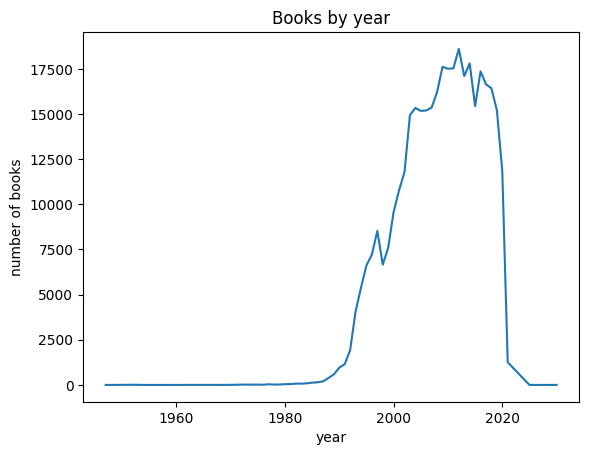

In [177]:
plt.plot(count_by_year.index, count_by_year.values)
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.show()

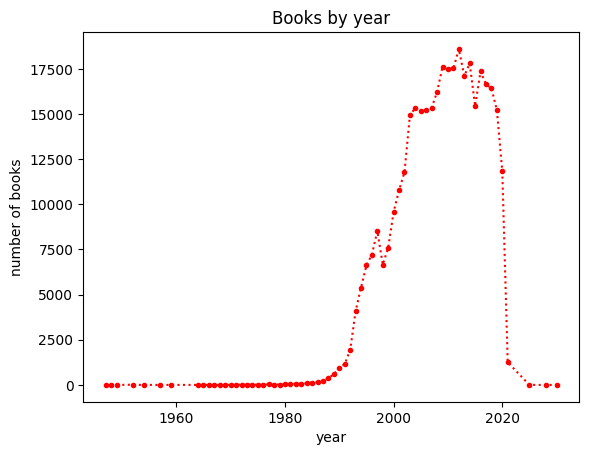

In [178]:
plt.plot(count_by_year, marker='.', linestyle=':', color='red')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.show()

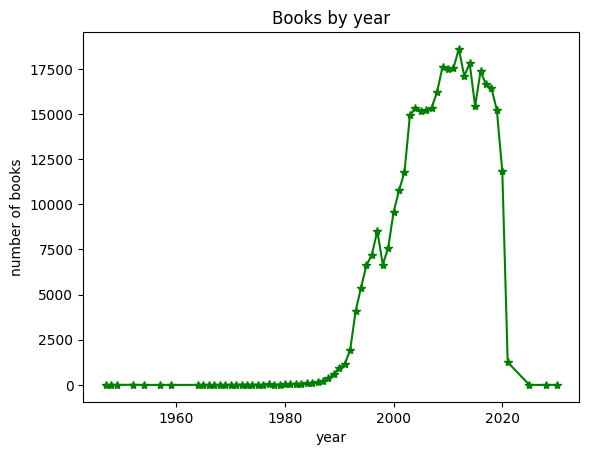

In [179]:
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.show()

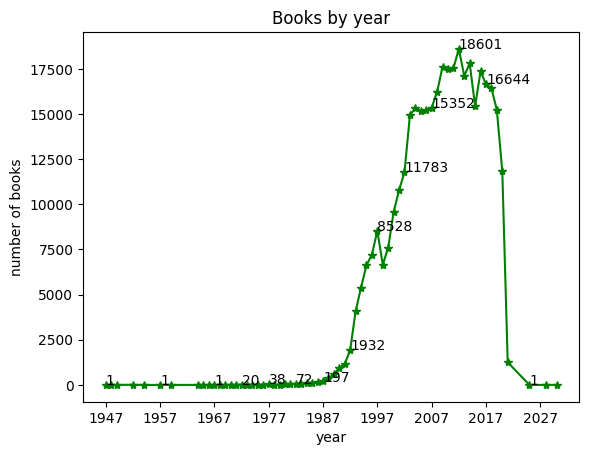

In [180]:
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val))
plt.show()

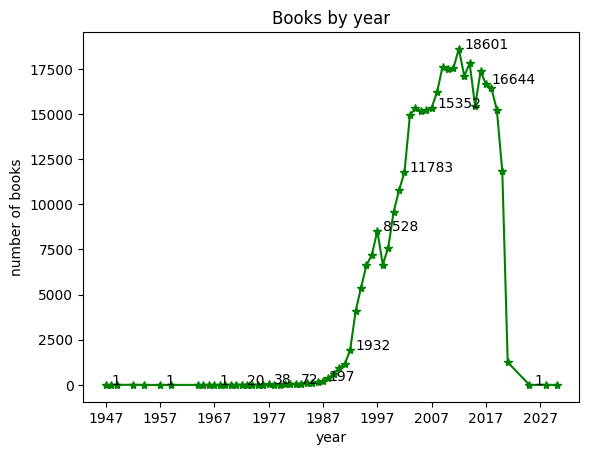

In [181]:
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(idx+1, val+10))   # xytext로 텍스트를 마커에서 조금 떼어놓기
plt.show()

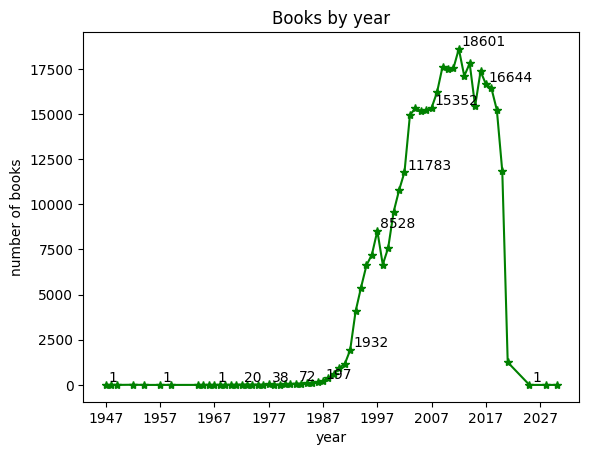

In [182]:
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(2, 2), textcoords='offset points')    # 상대적인 위치를 포인트나 픽셀 단위로 지정
plt.show()

### **4) 막대 그래프 그리기**
- bar() 함수로 막대 그래프 그림

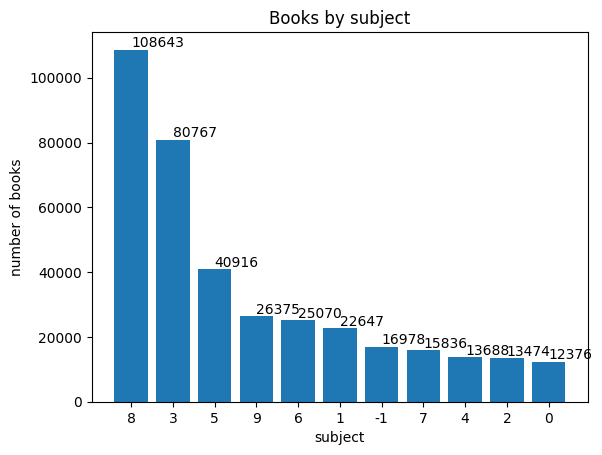

In [183]:
plt.bar(count_by_subject.index, count_by_subject.values)
# x축에는 인덱스인 주제분류번호, y축에는 도서 개수를 전달
plt.title('Books by subject')
plt.xlabel('subject')
plt.ylabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0, 2), textcoords='offset points')
plt.show()

**텍스트 정렬, 막대 조절 및 색상 바꾸기**

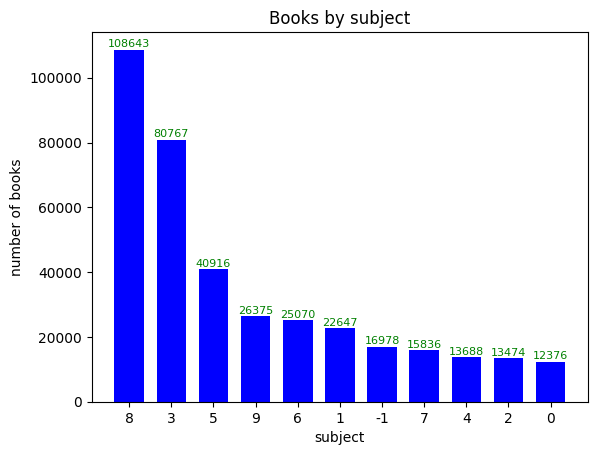

In [184]:
plt.bar(count_by_subject.index, count_by_subject.values, width=0.7, color='blue')
plt.title('Books by subject')
plt.xlabel('subject')
plt.ylabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0, 2), textcoords='offset points',
                 fontsize=8, ha='center', color='green')
plt.show()

**가로 막대 그래프 그리기**
- 막대의 두께를 나타내는 매개변수는 height

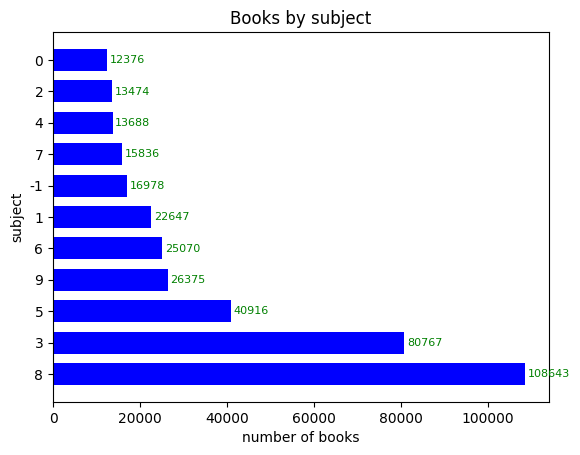

In [185]:
plt.barh(count_by_subject.index, count_by_subject.values, height=0.7, color='blue')
plt.title('Books by subject')
plt.xlabel('number of books')
plt.ylabel('subject')
for idx, val in count_by_subject.items():
    plt.annotate(val, (val, idx), xytext=(2, 0), textcoords='offset points',
                 fontsize=8, va='center', color='green')
plt.show()